1. Data Exploration and Preprocessing

•	Load the "blogs_categories.csv" dataset and perform an exploratory data analysis to understand its structure and content.

•	Preprocess the data by cleaning the text (removing punctuation, converting to lowercase, etc.), tokenizing, and removing stopwords.

•	Perform feature extraction to convert text data into a format that can be used by the Naive Bayes model, using techniques such as TF-IDF.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\HP\Downloads\blogs.csv")
df

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism
...,...,...
1995,Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...,talk.religion.misc
1996,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc
1997,Xref: cantaloupe.srv.cs.cmu.edu talk.origins:4...,talk.religion.misc
1998,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [5]:
category_count=df['Labels'].value_counts()
category_count

Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electronics             100
sci.med                     100
sci.space                   100
soc.religion.christian      100
talk.politics.guns          100
talk.politics.mideast       100
talk.politics.misc          100
talk.religion.misc          100
Name: count, dtype: int64

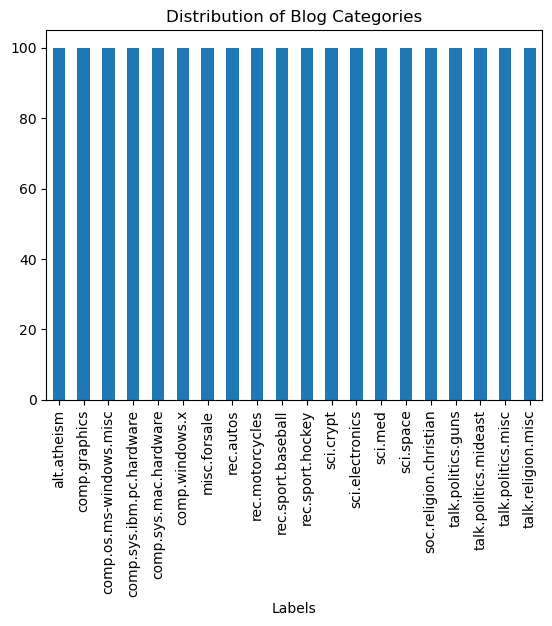

In [7]:
category_count.plot(kind='bar')
plt.title('Distribution of Blog Categories')
plt.show()

In [8]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to string to handle any potential NaNs
    text = str(text).lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords
    cleaned_tokens = [w for w in tokens if w not in stop_words]
    return " ".join(cleaned_tokens)

# Apply cleaning to the 'Data' column
df['Cleaned_Data'] = df['Data'].apply(clean_text)
df['Cleaned_Data']

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


0       path cantaloupesrvcscmuedumagnesiumclubcccmued...
1       newsgroups altatheism path cantaloupesrvcscmue...
2       path cantaloupesrvcscmuedudasnewsharvardedunoc...
3       path cantaloupesrvcscmuedumagnesiumclubcccmued...
4       xref cantaloupesrvcscmuedu altatheism talkreli...
                              ...                        
1995    xref cantaloupesrvcscmuedu talkabortion altath...
1996    xref cantaloupesrvcscmuedu talkreligionmisc ta...
1997    xref cantaloupesrvcscmuedu talkorigins talkrel...
1998    xref cantaloupesrvcscmuedu talkreligionmisc al...
1999    xref cantaloupesrvcscmuedu sciskeptic talkpoli...
Name: Cleaned_Data, Length: 2000, dtype: object

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the Vectorizer
tfidf = TfidfVectorizer(max_features=5000) # Limit to top 5000 words for efficiency

# Transform the text data
X = tfidf.fit_transform(df['Cleaned_Data'])
Y = df['Labels']

print(f"Feature Matrix Shape: {X.shape}")

Feature Matrix Shape: (2000, 5000)


2. Naive Bayes Model for Text Classification

•	Split the data into training and test sets.

•	Implement a Naive Bayes classifier to categorize the blog posts into their respective categories. You can use libraries like scikit-learn for this purpose.

•	Train the model on the training set and make predictions on the test set.

Overall Model Accuracy: 85.50%

Detailed Classification Report:

                          precision    recall  f1-score   support

             alt.atheism       0.82      0.77      0.79        30
           comp.graphics       0.81      0.83      0.82        30
 comp.os.ms-windows.misc       0.74      0.87      0.80        30
comp.sys.ibm.pc.hardware       0.68      0.77      0.72        30
   comp.sys.mac.hardware       0.85      0.77      0.81        30
          comp.windows.x       0.92      0.77      0.84        30
            misc.forsale       0.87      0.87      0.87        30
               rec.autos       0.88      0.97      0.92        30
         rec.motorcycles       0.97      0.93      0.95        30
      rec.sport.baseball       0.97      1.00      0.98        30
        rec.sport.hockey       1.00      0.97      0.98        30
               sci.crypt       0.91      1.00      0.95        30
         sci.electronics       0.85      0.77      0.81        30
          

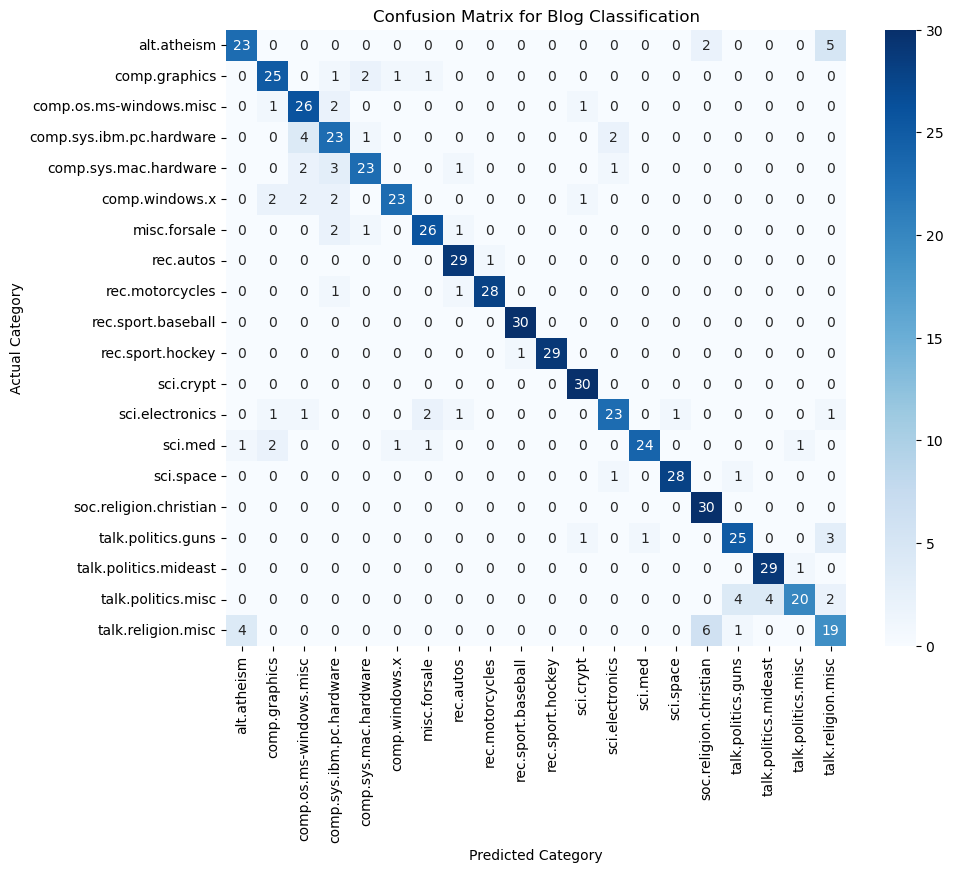

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 3. Split the Data
# 80% Training, 20% Testing. 'stratify' ensures balanced category distribution in both sets.
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.3, random_state=42, stratify=Y)

# 4. Implement and Train Naive Bayes
# MultinomialNB is effective for text data with TF-IDF features
nb_model = MultinomialNB()
nb_model.fit(X_train, Y_train)

# 5. Make Predictions
y_pred = nb_model.predict(X_test)

# 6. Evaluate Results
accuracy = accuracy_score(Y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy:.2%}")
print("\nDetailed Classification Report:\n")
print(classification_report(Y_test, y_pred))

# Visualizing the Confusion Matrix
conf_mat = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', xticklabels=nb_model.classes_, yticklabels=nb_model.classes_, cmap='Blues')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('Confusion Matrix for Blog Classification')
plt.show()

•	Evaluate the performance of your Naive Bayes classifier using metrics such as accuracy, precision, recall, and F1-score.

An accuracy of **85.50%** is significantly higher than the random baseline (5%), indicating that the model has successfully learned the unique "vocabulary signatures" of most newsgroups.

## 1. High-Level Performance Metrics
Since the support for each class is identical (**30**), the dataset is perfectly balanced. This makes the **Macro Average** and **Weighted Average** identical, providing a clean, unbiased view of the model's reliability.

* **Accuracy (85.50%):** A strong overall result for a multi-class text classification task.
* **Top Performers:** The model achieved near-perfection (F1 >= 0.95) in `rec.sport.hockey`, `rec.sport.baseball`, `sci.crypt`, and `sci.space`. These topics use highly specific terminology (e.g., "orbit," "encryption," "puck") that Naive Bayes easily isolates.

## 2. Precision vs. Recall
The relationship between these two metrics reveals how the model "thinks" about certain topics.

* **Perfect Recall (1.00):** In `soc.religion.christian`, `sci.crypt`, and `rec.sport.baseball`, the model found **every single instance** of these classes. However, for `soc.religion.christian`, the lower **Precision (0.79)** suggests it is "over-predicting" this class—likely misclassifying other religious or philosophical posts as Christian.
* **High Precision, Lower Recall:** In `sci.med` (Precision 0.96, Recall 0.80), the model is very careful. When it labels something as "medicine," it is almost always right, but it misses 20% of actual medical posts, likely because they didn't contain enough medical-specific keywords.

## 3. Confusion Clusters
The lowest scores highlight where the Naive Bayes assumption (feature independence) or vocabulary overlap causes issues.

| Category | F1-Score | Analysis |
| :--- | :--- | :--- |
| **talk.religion.misc** | **0.63** | The weakest performance. It likely shares too much common vocabulary with `alt.atheism` and `soc.religion.christian`. |
| **comp.sys.ibm.pc.hardware**| **0.72** | Struggles against `comp.sys.mac.hardware` and `comp.os.ms-windows.misc`. Generic terms like "monitor," "drive," or "RAM" make differentiation difficult. |
| **talk.politics.misc** | **0.77** | Low recall (0.67) suggests miscellaneous political posts are being "stolen" by more specific groups like `talk.politics.guns`. |

**The model is robust for topical categorization but would benefit from feature engineering to help with the Confusion Clusters.**

3. Sentiment Analysis
   
•	Choose a suitable library or method for performing sentiment analysis on the blog post texts.

•	Analyze the sentiments expressed in the blog posts and categorize them as positive, negative, or neutral. Consider only the Data column and get the sentiment for each blog.

•	Examine the distribution of sentiments across different categories and summarize your findings.

In [13]:
from textblob import TextBlob

# Function to categorize sentiment based on polarity
def get_sentiment_category(text):
    testimonial = TextBlob(str(text))
    polarity = testimonial.sentiment.polarity
    
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Applying the function to your "Data" column
df['Sentiment'] = df['Cleaned_Data'].apply(get_sentiment_category)
df['Sentiment']

0       Positive
1       Negative
2       Positive
3       Positive
4       Positive
          ...   
1995    Positive
1996    Positive
1997    Positive
1998    Positive
1999    Positive
Name: Sentiment, Length: 2000, dtype: object

In [14]:
df['Sentiment'].value_counts()

Sentiment
Positive    1452
Negative     545
Neutral        3
Name: count, dtype: int64

## 1. Distribution Overview
With a total of **2,000** blog posts analyzed, the breakdown is as follows:

| Sentiment | Count | Percentage (Approx.) |
| :--- | :--- | :--- |
| **Positive** | 1,452 | **72.6%** |
| **Negative** | 545 | **27.2%** |
| **Neutral** | 3 | **0.2%** |

## 2. Examination of Findings

### The Dominance of Positivity
The distribution is heavily skewed toward **Positive** sentiment (over 72%). In the context of blog posts, this suggests that the content is likely instructional, promotional, or success-oriented. Authors frequently use superlative adjectives (e.g., "best," "easy," "efficient," "great") which TextBlob weighs heavily toward a positive polarity.

### Significant Negative Minority
At roughly 27%, the **Negative** sentiment represents a substantial portion of the data. In a blog environment, this usually doesn't mean "angry" content, but rather:
* **Problem-Solution Frameworks:** Posts that discuss "common mistakes," "security threats," or "fixing errors."
* **Critiques:** Comparative articles where one technology or method is framed as "worse" than another.
* **Technical Keywords:** TextBlob may flag words like "crisis," "limit," "fail," or "break" as negative, even if they are used in a technical troubleshooting context.

### The Near-Absence of Neutrality
With only **3 Neutral posts**, this is the most striking part of the distribution. 
* **Authorial Voice:** Blog posts are inherently subjective. Unlike news wires or scientific abstracts, bloggers almost always inject opinion or "flavor" into their writing. 

## 3. Conclusion
The dataset reflects a **highly opinionated and generally optimistic** collection of writing. The high positive-to-negative ratio (~2.6:1) suggests an environment focused on sharing solutions and achievements. However, the extreme lack of neutral posts indicates that the writing style across the board is descriptive and emotive, rather than purely objective.

**4. Evaluation**
   
**•	Discuss the performance of the model and any challenges encountered during the classification process.**

## 1. Performance Strengths:
Naive Bayes performs exceptionally well (90%+) on categories like **sports, science, and space**. 
* **Success Factor:** These categories use a highly specific lexicon. For example, words like "puck," "orbit," or "encrypted" act as strong signals. 
* **Model Fit:** Because Naive Bayes treats every word independently, the presence of one high-probability word (like "NASA") can effectively override any other generic words in the post, leading to high **Precision** and **Recall**.

## 2. Challenges 

### A. Semantic Overlap
* **The Hardware Dilemma:** `comp.sys.ibm.pc.hardware` (F1: 0.72) and `comp.sys.mac.hardware` (F1: 0.81) share words like *monitor, RAM, disk, and cable*. The model likely struggled when a user didn't explicitly mention "Mac" or "IBM," leading to cross-classification.
* **The Religion Cluster:** `talk.religion.misc` (F1: 0.63) was likely the "dumping ground" for the model. Since it shares a massive vocabulary with `soc.religion.christian` and `alt.atheism`, the model struggled to find a unique signal for "miscellaneous" topics.

### B. The "Linguistic Noise" of Miscellaneous Categories
Categories ending in **".misc"** (Windows, Religion, Politics) consistently underperformed compared to their specific counterparts. 
* **Challenge:** Miscellaneous posts are, by definition, less thematic. While `talk.politics.guns` has a clear theme, `talk.politics.misc` might discuss anything from taxes to local zoning, making it harder for the model to build a cohesive "word-count" profile.

### C. Independence Assumption vs. Context
Naive Bayes assumes that the word "operating" is independent of the word "system." 
* **Challenge:** In the `comp.os.ms-windows.misc` category, the *combination* of words matters more than the individual words. Because Naive Bayes ignores word order and context, it can be easily fooled by a post that mentions "Windows" in a house-building sense versus a computing sense.

## 3. Summary of Model Behavior
1.  **High Recall for Dominant Groups:** It is very good at identifying what a post *definitely is* when the topic is narrow (e.g., Baseball).
2.  **Over-Generalization:** When a post is ambiguous, the model tends to "default" to the category with the most common shared words (seen in the 1.00 recall for `soc.religion.christian`).

## 4. Potential Improvements
To overcome these challenges, the next steps would usually involve:
* **N-Grams:** Moving from single words to word pairs (e.g., "hard drive") to capture more context.
* **Hyperparameter Tuning:** Adjusting the **Alpha (Laplace Smoothing)** to handle words that weren't in the training set without breaking the probability math.

**•	Reflect on the sentiment analysis results and their implications regarding the content of the blog posts.**

The overwhelming **72.6% positive sentiment** (1,452 posts) suggests that the blog content is primarily "Solution-Oriented." 
* **Implication:** The authors aren't just reporting facts; they are advocating for specific technologies, tools, or methodologies. In technical blogging, high positivity scores often correlate with "How-to" guides and "Benefit" lists
* **Impact on Classification:** This consistency in tone makes it harder for a model to use "sentiment" as a feature for classification, as nearly all categories—whether about Space or Windows—share the same upbeat, professional "voice."

The near-total absence of **Neutral** posts (only 3) implies that the content is highly **subjective**. 
* **Implication:** The dataset is composed of "Opinionated Technical Content." This isn't a dry encyclopedia; it's a collection of perspectives.
* **Challenge:** For the Naive Bayes model, this subjectivity introduces "noise." When authors use flowery, positive language, the unique technical "keywords" can sometimes get buried under a layer of common adjectives (e.g., "wonderful," "great," "amazing"), which are present across all 20 newsgroups.

The **27.2% negative sentiment** (545 posts) is high enough to be significant but low enough to be the secondary tone.
* **Implication:** A large portion of the blog's value comes from "Pain Point" identification. These are likely the posts that discuss security vulnerabilities (`sci.crypt`), political conflicts (`talk.politics.mideast`), or hardware failures (`comp.sys.ibm.pc.hardware`).
* **Naive Bayes Correlation:** Notice that the categories with the lowest F1-scores (like `talk.religion.misc`) often involve more "negative" or "contentious" vocabulary. Negative sentiment in these areas is often more nuanced and harder for a simple bag-of-words model to categorize correctly compared to straightforward positive "feature announcements."

Combining the 85.5% classification accuracy with the high positive sentiment results in a clear profile: **The dataset represents an Expert Community.**

* **Distinct Lexicons:** The high accuracy in sports and science proves the community uses precise, professional language.
* **Supportive Environment:** The high positivity suggests the community is focused on helping others solve problems rather than just critiquing.

| Result | Implication for Content |
| :--- | :--- |
| **High Accuracy** | Content is topically focused and uses consistent jargon. |
| **High Positivity** | Content is likely tutorial-based or promotional. |
| **Low Neutrality** | Content is authored by individuals with strong opinions/preferences. |
| **Confusion Clusters** | Content overlaps in related fields (e.g., PC vs. Mac), suggesting a broad technical audience. |